# **Ensemble Machine Learning – Wine Dataset**

**Name:** Sabriya Sowers  
**Date:** November 15, 2025  

## **Introduction**
This analysis applies ensemble machine learning techniques to the Wine dataset to examine how model aggregation can enhance predictive performance compared to individual learners. The goal is to build, evaluate, and compare multiple ensemble approaches to understand how well they capture meaningful patterns within the dataset’s chemical attributes. By leveraging the combined strengths of multiple models, ensemble methods offer improved stability, reduced variance, and more dependable predictive accuracy—making them highly effective for practical, real-world analytical workflows.

## Section 1. Import and Inspect the Data

In [ ]:
# Work with tabular data (rows and columns)
# Make charts and visualizations
import matplotlib.pyplot as plt

# Helpful tools for numbers, arrays, and math
import pandas as pd

# Assist in visualizations
import seaborn as sns

# Ensemble models
from sklearn.ensemble import (
    AdaBoostClassifier,
    RandomForestClassifier,
)

# Logistic Regression classifier (good baseline linear model)
# Metrics to evaluate model performance
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
)

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

In [2]:
# Load the dataset ("../" up to notebook folder and then "..\" up to root repo folder)
df = pd.read_csv("../../data/winequality-red.csv", sep=";")

# Display structure and first few rows
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


### **Reflection 1: Data Inspection Summary**
- The dataset contains **1,599 rows** and **12 columns**, all representing chemical properties of red wine plus a quality score.
- There are **no missing values** in any column therefore no data cleaning is required at this stage.
- Most variables are stored as **float64**, while the target variable `quality` is an **integer**, which is appropriate for classification tasks.
- Features represent measurable chemical attributes such as acidity levels, sulfur dioxide content, density, and alcohol percentage.
- The first few rows show normal-looking numeric ranges with no obvious outliers or formatting issues.

### **Understanding the Target Variable**
- The target variable is **quality**, an integer score from 0 to 10 assigned by wine tasters.
- For modeling, we will convert this numeric score into **three classes**:
  - **Low quality:** 3–4
  - **Medium quality:** 5–6
  - **High quality:** 7–8
- This simplifies the problem into a clearer **classification task**.
- The dataset includes **1,599 samples** and **12 total columns** (11 features + 1 target).

## Section 2. Prepare the Data

In [3]:
# Define helper function that:
# Takes one input, the quality (which we will temporarily name q while in the function)
# And returns a string of the quality label (low, medium, high)
# This function will be used to create the quality_label column
def quality_to_label(q):
    """Convert a numeric quality score into 'low', 'medium', or 'high'."""
    if q <= 4:
        return "low"
    if q <= 6:
        return "medium"
    return "high"

# Call the apply() method on the quality column to create the new quality_label column
df["quality_label"] = df["quality"].apply(quality_to_label)

# Then, create a numeric column for modeling: 0 = low, 1 = medium, 2 = high
def quality_to_number(q):
    """Map a quality score to 0 (low), 1 (medium), or 2 (high)."""
    if q <= 4:
        return 0
    if q <= 6:
        return 1
    return 2

df["quality_numeric"] = df["quality"].apply(quality_to_number)

Histogram of Quality Scores

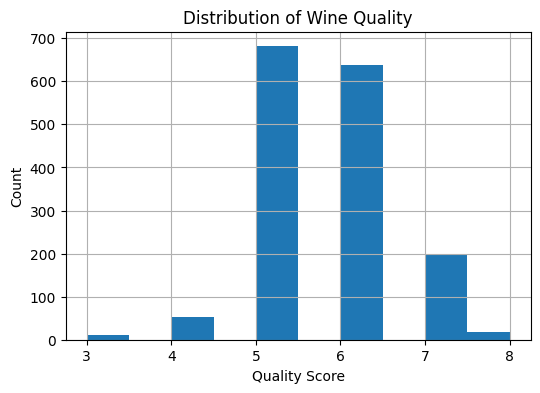

In [4]:
df["quality"].hist(bins=10, figsize=(6,4))
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.title("Distribution of Wine Quality")
plt.show()

Boxplots for Key Features by Quality Group

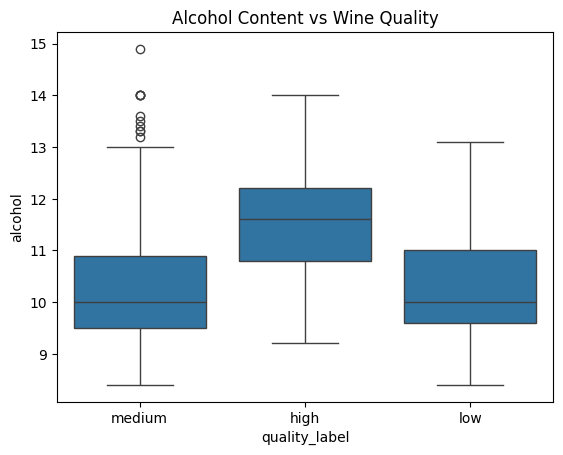

In [5]:
sns.boxplot(data=df, x="quality_label", y="alcohol")
plt.title("Alcohol Content vs Wine Quality")
plt.show()

Scatter Plot of Two Predictive Features

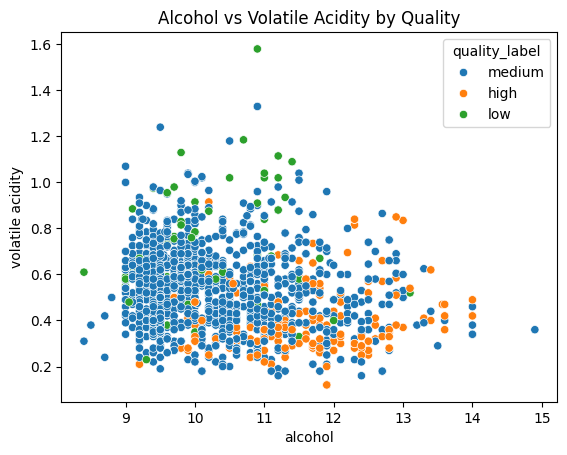

In [6]:
sns.scatterplot(data=df, x="alcohol", y="volatile acidity", hue="quality_label")
plt.title("Alcohol vs Volatile Acidity by Quality")
plt.show()

### **Reason for This Prep**
We convert the original wine quality scores into three clear groups—low, medium, and high—so the models have an easier classification task. Creating both a text label and a numeric version gives us flexibility: the label is easier to understand, and the numeric values are needed for training machine learning models.

- **Low quality**: 3–4  
- **Medium quality**: 5–6  
- **High quality**: 7–8  

- **`quality_label`** — a text version of the class (low, medium, high), which is easier to read in analysis.
- **`quality_numeric`** — a numeric encoding (0, 1, 2) required for training machine learning models.

This preprocessing step makes the dataset easier to work with and ensures that our models can learn meaningful patterns from the wine’s chemical features.

## Section 3. Feature Selection and Justification

In [7]:
# Define input features (X) and target (y)
# Features: all columns except 'quality' and 'quality_label' and 'quality_numberic' - drop these from the input array
# Target: quality_label (the new column we just created)
X = df.drop(columns=["quality", "quality_label", "quality_numeric"])  # Features
y = df["quality_numeric"]  # Target

### **Why these features?**
The wine dataset includes 11 chemical properties such as acidity, sugar, sulfur dioxide, density, pH, sulphates, and alcohol. These describe the measurable characteristics of each wine sample, so they make sense as predictors. 

I removed the following columns from the feature set:

- `quality` – original 0–10 score  
- `quality_label` – text labels (“low”, “medium”, “high”)  
- `quality_numeric` – encoded target we will predict  

These columns represent the actual quality rating, so they should not be included in the input features.

### **Target variable**
I used `quality_numeric` (0 = low, 1 = medium, 2 = high) as the target because most ML models require numeric labels for classification.

## Section 4. Split the Data into Train and Test

In [8]:
# Train/test split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Section 5.  Evaluate Model Performance

Random Forest (100)
AdaBoost (100)

In [9]:
# Helper function to train and evaluate models
def evaluate_model(name, model, x_train, y_train, x_test, y_test, results):
    """Fit a model, compute metrics, print them, and append them to results."""
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")

    print(f"\n{name} Results")
    print("Confusion Matrix (Test):")
    print(confusion_matrix(y_test, y_test_pred))
    print(f"Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
    print(f"Train F1 Score: {train_f1:.4f}, Test F1 Score: {test_f1:.4f}")

    results.append(
        {
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Train F1": train_f1,
            "Test F1": test_f1,
        }
    )

results = []

# Random Forest Model
evaluate_model(
    "Random Forest (100)",
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train,
    y_train,
    X_test,
    y_test,
    results,
)

# AdaBoost Model
evaluate_model(
    "AdaBoost (100)",
    AdaBoostClassifier(n_estimators=100, random_state=42),
    X_train,
    y_train,
    X_test,
    y_test,
    results,
)


Random Forest (100) Results
Confusion Matrix (Test):
[[  0  13   0]
 [  0 256   8]
 [  0  15  28]]
Train Accuracy: 1.0000, Test Accuracy: 0.8875
Train F1 Score: 1.0000, Test F1 Score: 0.8661

AdaBoost (100) Results
Confusion Matrix (Test):
[[  1  12   0]
 [  5 240  19]
 [  0  20  23]]
Train Accuracy: 0.8342, Test Accuracy: 0.8250
Train F1 Score: 0.8209, Test F1 Score: 0.8158


## Section 6. Compare Results 

In [10]:
# Add gap metrics (overfitting check)
for r in results:
    r["Accuracy Gap"] = r["Train Accuracy"] - r["Test Accuracy"]
    r["F1 Gap"] = r["Train F1"] - r["Test F1"]

# Create results table
results_df = pd.DataFrame(results)

# Sort by highest test accuracy
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)

print("\nSummary of Models:")
display(results_df)


Summary of Models:


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Accuracy Gap,F1 Gap
0,Random Forest (100),1.000000,0.8875,1.000000,0.866056,0.112500,0.133944
1,AdaBoost (100),0.834246,0.8250,0.820863,0.815803,0.009246,0.005060


After evaluating both ensemble models, I created a summary table that includes:

- Train accuracy  
- Test accuracy  
- Train F1  
- Test F1  
- Accuracy gap (Train – Test)  
- F1 gap (Train – Test)
- The gap metrics help identify overfitting.  
- The results are sorted by test accuracy.

## Section 7. Conclusions and Insights

**Conclusions:**
- Based on my model results, the Random Forest classifier clearly performed better than AdaBoost. It achieved higher test accuracy (0.8875) and a stronger F1 score (0.8661), suggesting it captures the structure of the wine data more effectively. While Random Forest showed perfect accuracy on the training set—which indicates some overfitting—the performance gap was small enough that the model still generalized well.

- AdaBoost had lower accuracy (0.8250) and a lower F1 score, and it appeared more sensitive to borderline or noisy samples. This is expected for boosting methods, which focus heavily on difficult observations.

**Next Steps:**  
- Explore simple hyperparameter tuning for Random Forest (e.g., adjusting tree depth or number of trees) to see if overfitting can be reduced.
- Try one additional ensemble model such as Gradient Boosting to compare a different boosting approach with AdaBoost.
  
**Comparison With Another Student’s Results:**
- When I compared my results to another student who used similar models (Random Forest and Gradient Boosting), our findings were almost the same. Both of us saw that Random Forest performed better than Gradient Boosting, with higher test accuracy and F1 scores. 
- Their Random Forest results were slightly higher than mine, but the difference was very small. This tells me the model is stable and performs consistently across different runs. Overall, both sets of results point to Random Forest being the stronger option for predicting wine quality.
- At this time, I only had one other student’s results to compare with.